## Segmentacja obrazu

Segmentacja obrazu to proces podziału obrazu na spójne, znaczące obszary (segmenty), które odpowiadają obiektom lub ich częściom i są jednorodne według wybranych cech, takich jak jasność, kolor, tekstura czy położenie przestrzenne.

Celem segmentacji jest uproszczenie obrazu i wydzielenie informacji istotnej do dalszej analizy, np. pomiarów, rozpoznawania obiektów lub śledzenia.

# Progowanie globalne + Otsu

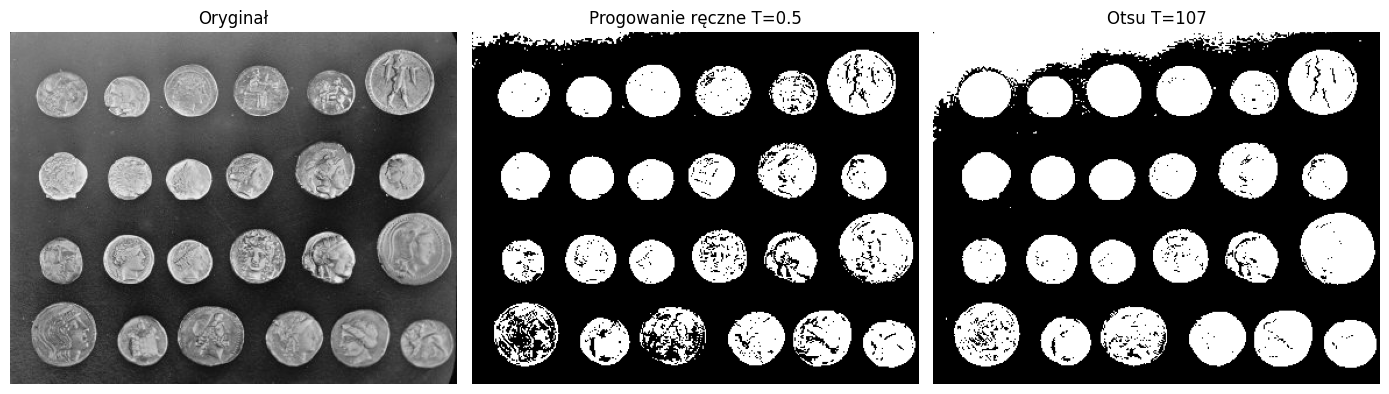

In [ ]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from skimage.util import img_as_float

def show(imgs, titles, cmap="gray", figsize=(14,4)):
    plt.figure(figsize=figsize)
    for i,(im,t) in enumerate(zip(imgs,titles),1):
        ax=plt.subplot(1,len(imgs),i)
        ax.imshow(im, cmap=cmap)
        ax.axis("off")
        ax.set_title(t)
    plt.tight_layout()
    plt.show()

img = data.coins()
img_f = img_as_float(img)

T_manual = 0.50
mask_manual = img_f > T_manual

T_otsu = threshold_otsu(img)
mask_otsu = img > T_otsu

show(
    [img, mask_manual, mask_otsu],
    ["Oryginał", f"Progowanie ręczne T={T_manual}", f"Otsu T={T_otsu}"]
)

Wnioski:
Progowanie globalne silnie zależy od doboru progu. Ręcznie ustawiona wartość T=0.5 daje wynik przypadkowy i niedopasowany do rozkładu jasności obrazu, podczas gdy metoda Otsu automatycznie wyznacza próg na podstawie histogramu, skuteczniej rozdzielając obiekty (monety) od tła.

# Progowanie podwójne (przedział intensywności)

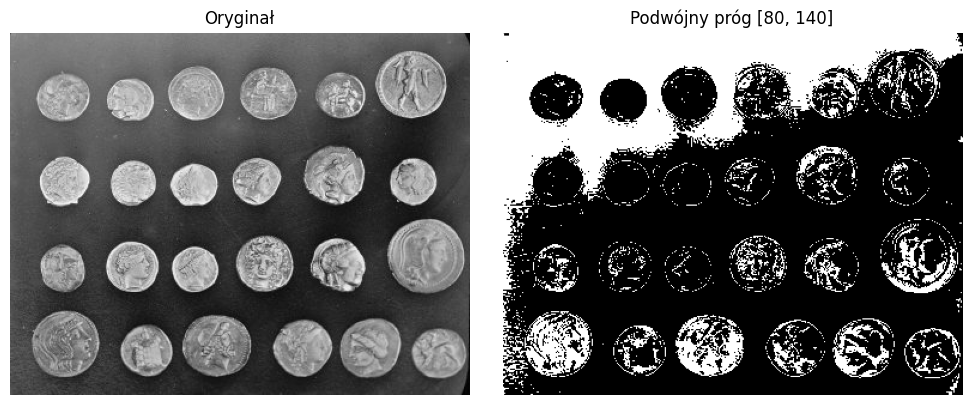

In [3]:
img = data.coins()

T1, T2 = 80, 140
mask_range = (img >= T1) & (img <= T2)

show([img, mask_range], ["Oryginał", f"Podwójny próg [{T1}, {T2}]"], figsize=(10, 4))

wnioski:
Progowanie podwójne pozwala wyodrębnić obiekty na podstawie zakresu jasności, a nie pojedynczego progu, dzięki czemu lepiej radzi sobie w sytuacjach, gdy interesujące struktury mają podobne wartości intensywności, ale różnią się zarówno od ciemnego, jak i jasnego tła.

## Progowanie adaptacyjne (lokalne) vs globalne

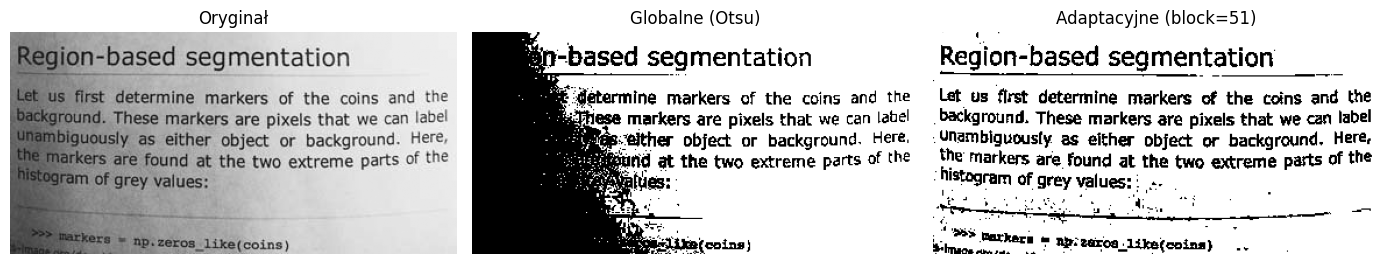

In [6]:
from skimage.filters import threshold_local

img = data.page()

# globalne (Otsu)
T_otsu = threshold_otsu(img)
mask_global = img > T_otsu

# lokalne (adaptive)
block_size = 51  # nieparzyste
T_local = threshold_local(img, block_size=block_size, method="gaussian", offset=5)
mask_local = img > T_local

show(
    [img, mask_global, mask_local],
    ["Oryginał", "Globalne (Otsu)", f"Adaptacyjne (block={block_size})"]
)

wniosek:
Progowanie globalne (Otsu) zawodzi w obecności niejednorodnego oświetlenia, ponieważ jeden próg nie jest w stanie poprawnie rozdzielić obiektów i tła w całym obrazie. Progowanie adaptacyjne, które wyznacza próg lokalnie w sąsiedztwie piksela, skutecznie kompensuje zmiany jasności tła i pozwala poprawnie wyodrębnić strukturę (tekst) na całym obrazie.

W praktyce oznacza to, że:
* Otsu działa dobrze tylko przy jednolitym tle i równym oświetleniu,
* progowanie adaptacyjne jest bardziej odporne na gradienty jasności i cienie,
* cena za lepszy wynik to większa liczba parametrów (rozmiar okna, offset) i większy koszt obliczeniowy.

## Progowanie barw (HSV) — przykładowe „czerwone” piksele

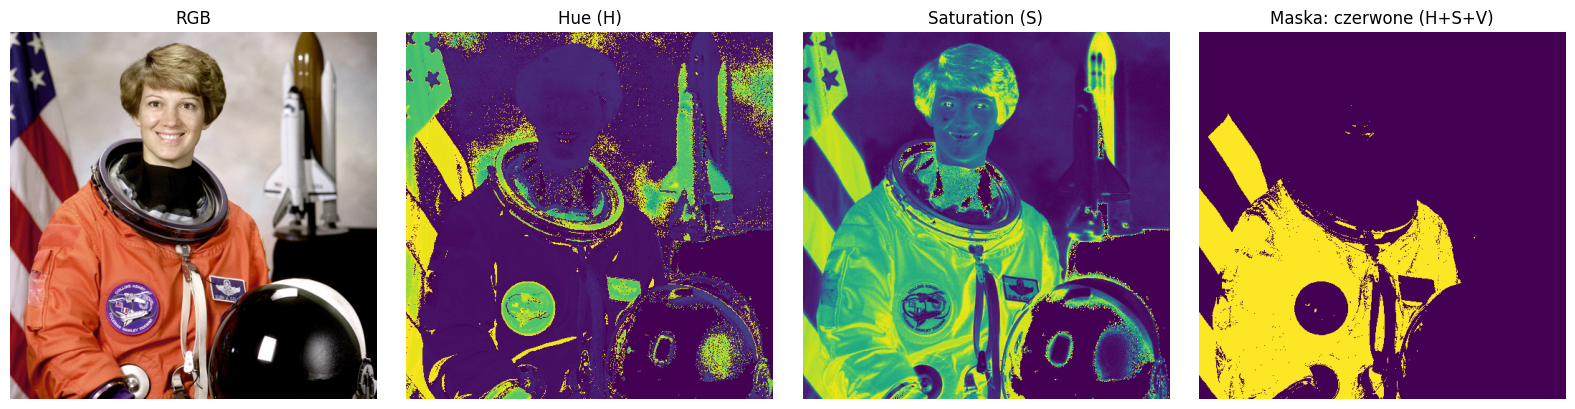

In [10]:
from skimage import color

rgb = data.astronaut()
hsv = color.rgb2hsv(rgb)
H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

# zakres "czerwieni": H blisko 0 lub 1 + sensowne S i V
mask_red = ((H < 0.05) | (H > 0.95)) & (S > 0.40) & (V > 0.20)

show(
    [rgb, H, S, mask_red],
    ["RGB", "Hue (H)", "Saturation (S)", "Maska: czerwone (H+S+V)"],
    cmap='viridis',
    figsize=(16, 4)
)

wniosek: Segmentacja oparta na barwie jest znacznie skuteczniejsza w przestrzeni HSV niż w RGB, ponieważ rozdziela informację o kolorze (Hue) od jasności (Value) i nasycenia (Saturation). Dzięki temu możliwe jest selektywne wyodrębnienie obiektów o określonej barwie (tu: czerwone elementy), niezależnie od ich oświetlenia.

W praktyce oznacza to, że:
* kanał Hue umożliwia bezpośrednie progowanie „po kolorze”, czego nie da się zrobić jednoznacznie w RGB,
* dodatkowe warunki na S i V eliminują piksele mało nasycone (szarości) i bardzo ciemne,
* metoda nadal wymaga ręcznego doboru zakresów, ale jest intuicyjna i skuteczna dla obiektów o wyraźnej barwie.

## Region Growing (rozrost obszaru):

* 1 seed
* stała wartość seeda jako wzorzec
* warunek |I(x,y) − I(seed)| ≤ T
* 8-sąsiedztwo
* bez wygładzania, bez gradientu, bez „ulepszeń”

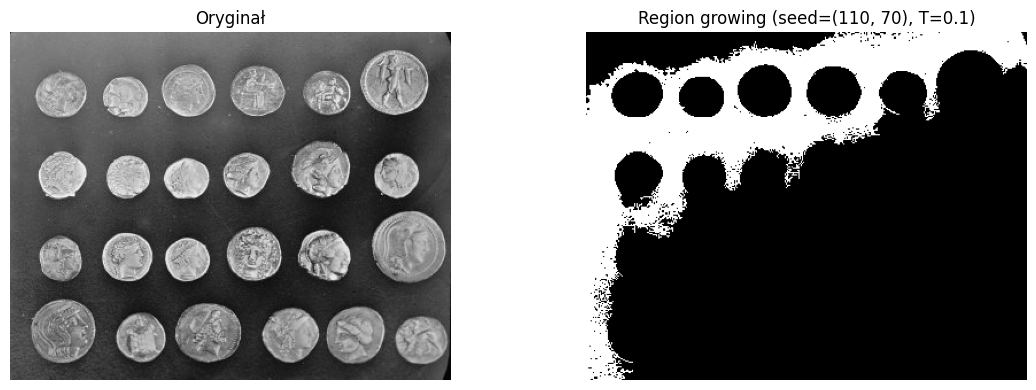

In [13]:
import numpy as np
from collections import deque

def region_growing(img, seed, T, connectivity=8):
    """
    Klasyczny region growing:
    |I(x,y) - I(seed)| <= T
    """
    img = img_as_float(img)
    h, w = img.shape
    sy, sx = seed
    seed_val = img[sy, sx]

    visited = np.zeros((h, w), dtype=bool)
    region = np.zeros((h, w), dtype=bool)

    if connectivity == 8:
        neighbors = [(-1,-1),(-1,0),(-1,1),
                     (0,-1),        (0,1),
                     (1,-1), (1,0), (1,1)]
    else:
        neighbors = [(-1,0),(1,0),(0,-1),(0,1)]

    q = deque()
    q.append((sy, sx))
    visited[sy, sx] = True

    while q:
        y, x = q.popleft()

        if abs(img[y, x] - seed_val) <= T:
            region[y, x] = True

            for dy, dx in neighbors:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                    visited[ny, nx] = True
                    q.append((ny, nx))

    return region

# --- DEMO ---
img = data.coins() # camera, coins, data.shepp_logan_phantom

seed = (110, 70)   # punkt startowy
T = 0.10           # tolerancja intensywności

mask = region_growing(img, seed, T)

show(
    [img, mask],
    ["Oryginał", f"Region growing (seed={seed}, T={T})"],
    figsize=(12, 4)
)

Jak to tłumaczyć:
* „Startujemy z jednego piksela (seed).
* Sprawdzamy sąsiadów — jeśli ich jasność jest podobna do jasności seeda, dołączają do regionu.
Region rośnie, aż nie ma już pikseli spełniających warunek.”

Parametry do zmiany na żywo:

seed → pokaż wrażliwość na punkt startowy

T → mały T → region się „kurczy”, duży T → „przecieka”

#Gegion growing + Gauss

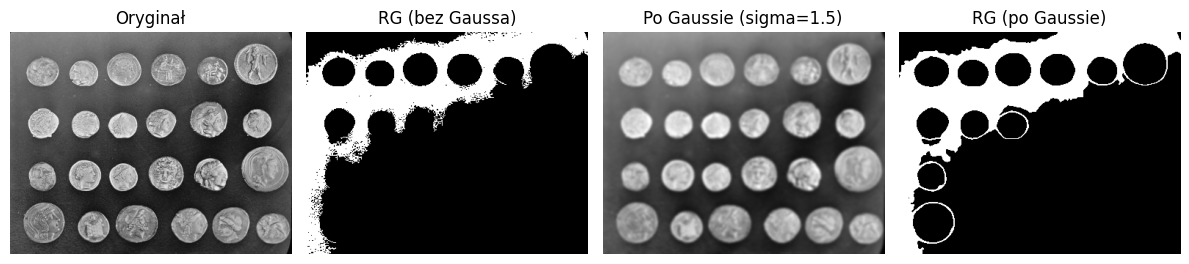

In [14]:
from skimage.filters import gaussian

# --- DEMO: region growing przed i po wygładzaniu Gaussa ---
img = data.coins()
img_f = img_as_float(img)

sigma = 1.5                 # siła wygładzania
img_g = gaussian(img_f, sigma=sigma)

seed = (110, 70)
T = 0.10                    # tolerancja (dla obrazu float w [0,1])

mask_raw = region_growing(img_f, seed, T)
mask_gauss = region_growing(img_g, seed, T)

show(
    [img_f, mask_raw, img_g, mask_gauss],
    ["Oryginał", "RG (bez Gaussa)", f"Po Gaussie (sigma={sigma})", "RG (po Gaussie)"],
    figsize=(12, 4)
)

Wygładzenie Gaussa istotnie wpływa na zachowanie algorytmu region growing. Redukcja szumu i drobnych fluktuacji jasności powoduje, że rozrost obszaru staje się bardziej stabilny i spójny, a wysegmentowany region ma gładsze granice i mniej przypadkowych „wysp”.

Wnioski:
W praktyce oznacza to, że:
* filtr Gaussa jest korzystnym krokiem wstępnym dla region growing, bo zmniejsza wrażliwość na szum,
* zbyt silne wygładzenie prowadzi do utraty informacji o krawędziach i pogorszenia lokalizacji granic,
* parametry sigma (wygładzenie) i T (tolerancja) muszą być dobierane wspólnie.

Watershed bez markerów (oversegmentation)

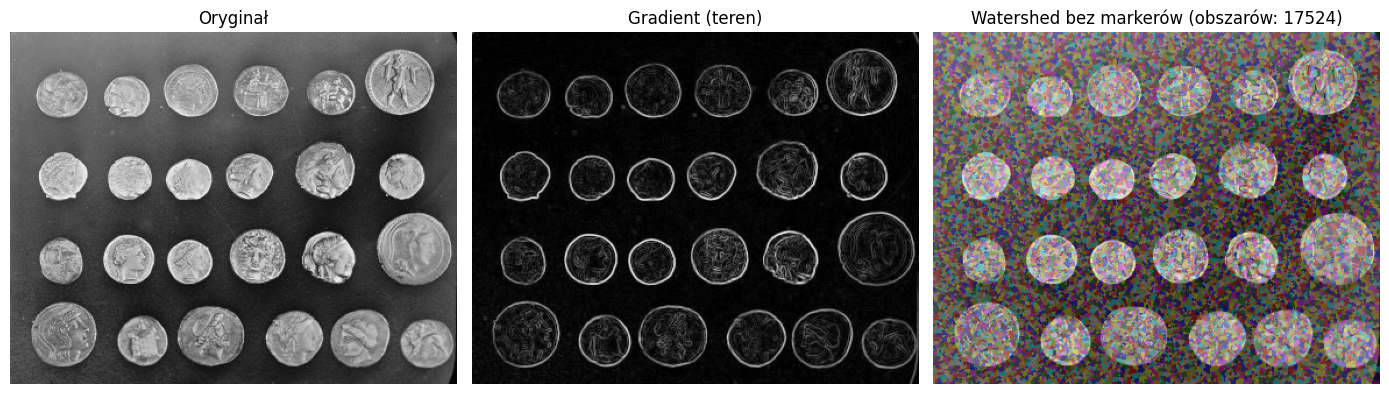

In [15]:
from skimage.filters import sobel
from skimage.segmentation import watershed

img = data.coins()
img_f = img_as_float(img)

grad = sobel(img_f)
labels_plain = watershed(grad)

overlay = color.label2rgb(labels_plain, image=img, bg_label=0)

show(
    [img, grad, overlay],
    ["Oryginał", "Gradient (teren)", f"Watershed bez markerów (obszarów: {labels_plain.max()})"],
    cmap="gray"
)

Zastosowanie algorytmu watershed bez markerów, bezpośrednio na mapie gradientu, prowadzi do silnej nadsegmentacji (oversegmentation). Każde lokalne minimum gradientu jest traktowane jako osobne źródło „zalewania”, co skutkuje powstaniem bardzo dużej liczby małych, często nieistotnych regionów.

W praktyce oznacza to, że:
* watershed jest niezwykle wrażliwy na szum i drobne fluktuacje gradientu,
* bez kontroli liczby minimów wynik jest trudny do interpretacji i bezużyteczny do dalszej analizy,
* sam gradient nie wystarcza jako „teren” do sensownej segmentacji obiektów.

Watershed z markerami (marker-based)

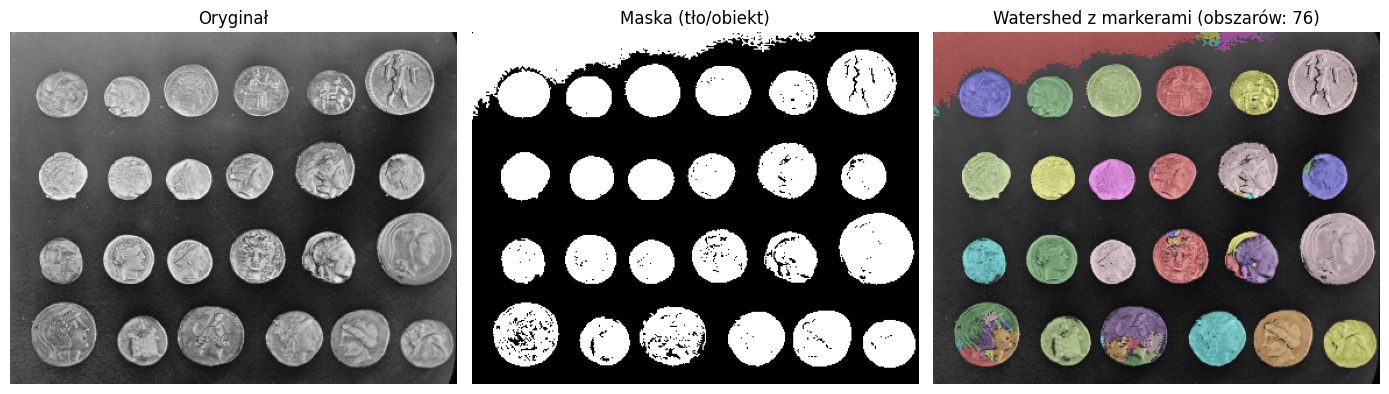

In [16]:
from skimage import morphology, measure

img = data.coins()
img_f = img_as_float(img)

# maska obiektu (prosto: Otsu + czyszczenie)
T = threshold_otsu(img)
bw = img > T
bw = morphology.remove_small_objects(bw, 50)

# markery: "pewne wnętrza" (erosion) -> etykiety
markers = measure.label(morphology.erosion(bw, morphology.disk(2)))

# teren: gradient (po lekkim wygładzeniu)
grad = sobel(gaussian(img_f, sigma=1.0))

labels_mark = watershed(grad, markers=markers, mask=bw)
overlay = color.label2rgb(labels_mark, image=img, bg_label=0)

show(
    [img, bw, overlay],
    ["Oryginał", "Maska (tło/obiekt)", f"Watershed z markerami (obszarów: {labels_mark.max()})"],
    cmap="gray"
)

Zastosowanie watershed z markerami skutecznie eliminuje problem nadsegmentacji widoczny w wersji bez markerów. Dzięki wprowadzeniu markerów reprezentujących „pewne wnętrza” obiektów, proces zalewania jest kontrolowany i prowadzi do powstania logicznych, spójnych regionów odpowiadających rzeczywistym obiektom (monetom).

W praktyce oznacza to, że:
* markery ograniczają liczbę źródeł zalewania, co stabilizuje wynik segmentacji,
* maska binarna zawęża obszar działania algorytmu tylko do potencjalnych obiektów,
* lekkie wygładzenie przed obliczeniem gradientu zmniejsza wpływ szumu, nie niszcząc głównych granic.

## Zadanie 1.

Segmentacja obrazu MRI mózgu

* Dane: skimage.data.brain()

Treść zadania:

1. Wczytaj obraz brain() i przeskaluj go do typu float.
2. Wykonaj segmentację trzema metodami:

* progowanie globalne (Otsu),
* progowanie adaptacyjne,
* region growing (1 seed umieszczony wewnątrz jasnego obszaru).

Dla każdej metody pokaż wynik i krótko go opisz.

Pytania do odpowiedzi:

* Dlaczego progowanie globalne nie rozdziela poprawnie wszystkich struktur?
* Jak zmienia się wynik region growing przy innym położeniu seeda?
* Która metoda najlepiej zachowuje spójność obszarów?

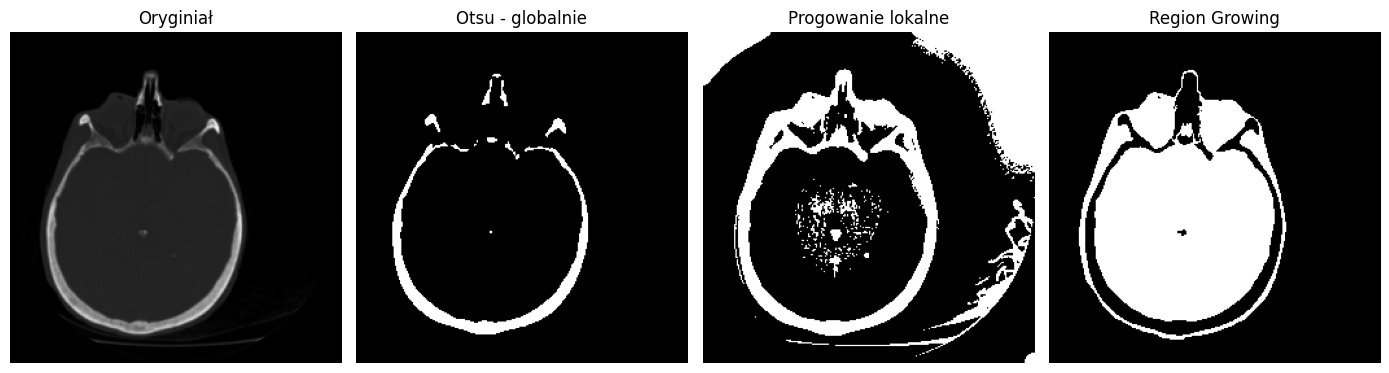

In [ ]:
img = data.brain()
img_f = img_as_float(img)

layer = 6

# otsu
T_otsu = threshold_otsu(img[layer])
mask_otsu = img[layer] > T_otsu

# adapcyjne
block_size = 101
T_local = threshold_local(img[layer], block_size=block_size, method="gaussian", offset=5)
mask_local = img[layer] > T_local

# region growing
seed = (128, 128)   # punkt startowy
T = 0.05            # tolerancja intensywności

mask_rg = region_growing(img[layer], seed, T)

show(
    [img_f[layer], mask_otsu, mask_local, mask_rg],
    ["Oryginiał", "Otsu - globalnie", "Progowanie lokalne", "Region Growing"]
)


#### Odpowiedzi

* Histogram jest dwumodlany przez co globalny próg może oddzielić tylko kość od mózgu i tła, przez co mózg jest uznawany jako tło.
* Dla `seed` na czaszce zaznaczona będzie czaszka; dla `seed` na tle będzie zaznaczone tło; analogicznie dla mózgu
* Moim zdaniem najlepiej działa region growing

### Inne przykładowe zdjęcia

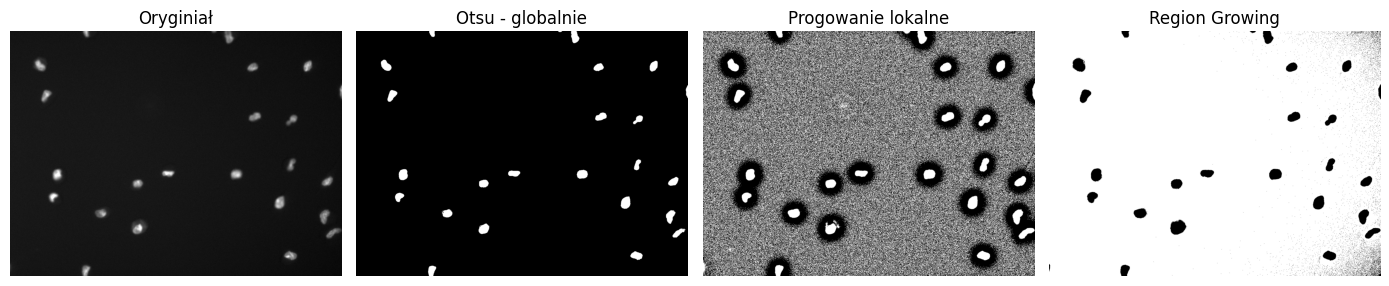

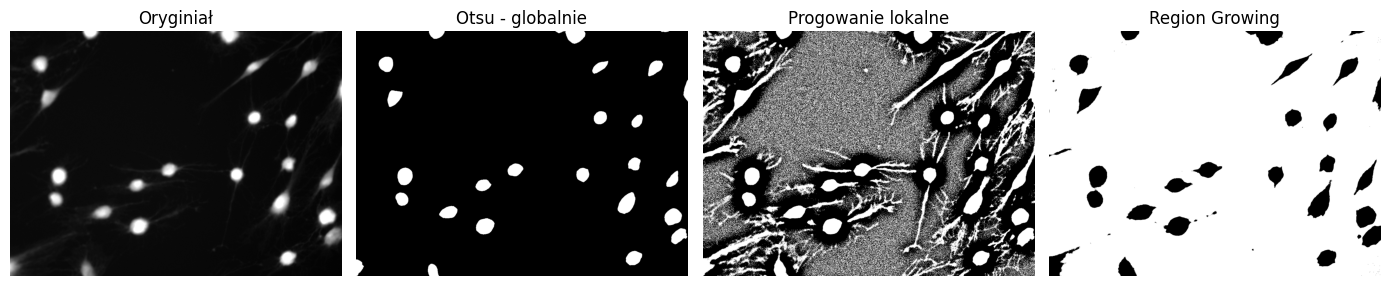

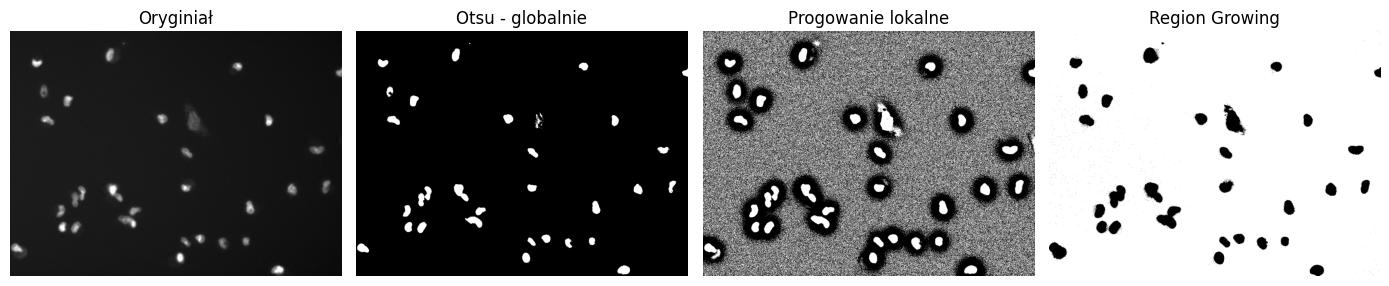

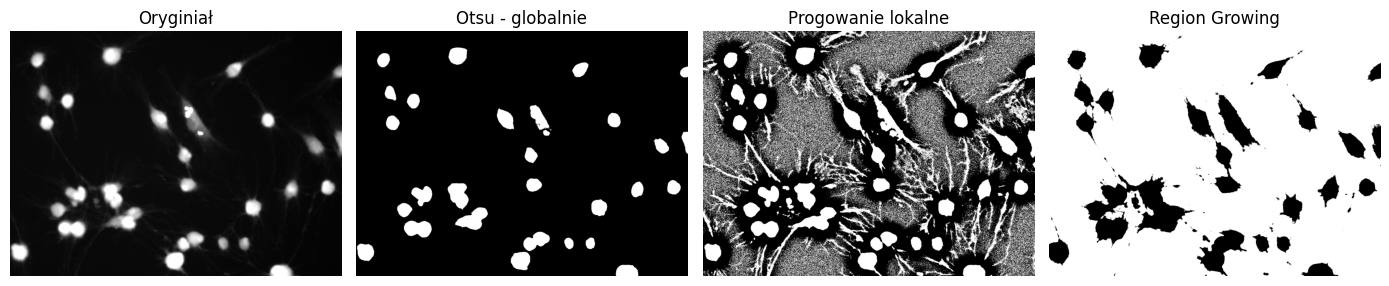

In [73]:
paths = [
    'data/zadanie 1/E02_02_DAPI.png', 'data/zadanie 1/E02_02_GFP.png', 'data/zadanie 1/E04_01_DAPI.png', 'data/zadanie 1/E04_01_GFP.png'
    ]

for path in paths:
    img = plt.imread(path, format='gray')
    img_f = img_as_float(img)

    # otsu
    T_otsu = threshold_otsu(img)
    mask_otsu = img > T_otsu

    # adapcyjne
    block_size = 101
    T_local = threshold_local(img, block_size=block_size, method="gaussian", offset=5)
    mask_local = img > T_local

    # region growing
    seed = (20, 50)     # punkt startowy
    T = 0.05            # tolerancja intensywności

    mask_rg = region_growing(img, seed, T)

    show(
        [img_f, mask_otsu, mask_local, mask_rg],
        ["Oryginiał", "Otsu - globalnie", "Progowanie lokalne", "Region Growing"]
    )

## Zadanie 2 – Watershed w obrazie medycznym

Dane: skimage.data.brain()

Treść zadania:

1. Oblicz gradient obrazu (np. Sobel).
2. Wykonaj watershed bez markerów i oceń wynik.
3. Następnie:

* utwórz maskę obiektu (np. progowanie + morfologia),
* wyznacz markery,
* wykonaj watershed z markerami.

4. Porównaj oba wyniki.
5. Pytania do odpowiedzi:

* Dlaczego watershed bez markerów prowadzi do nadsegmentacji?
* Jak markery wpływają na interpretowalność segmentów?
* Dlaczego watershed jest często stosowany w obrazach medycznych?

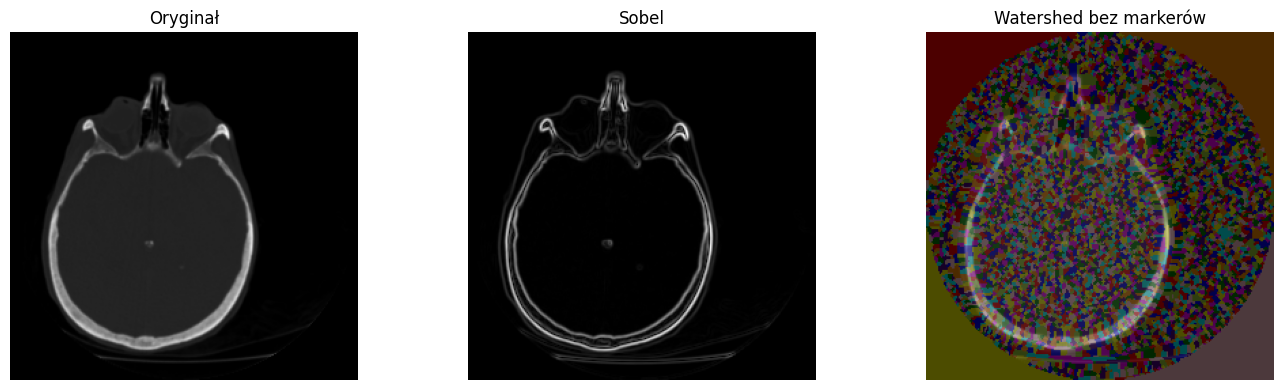

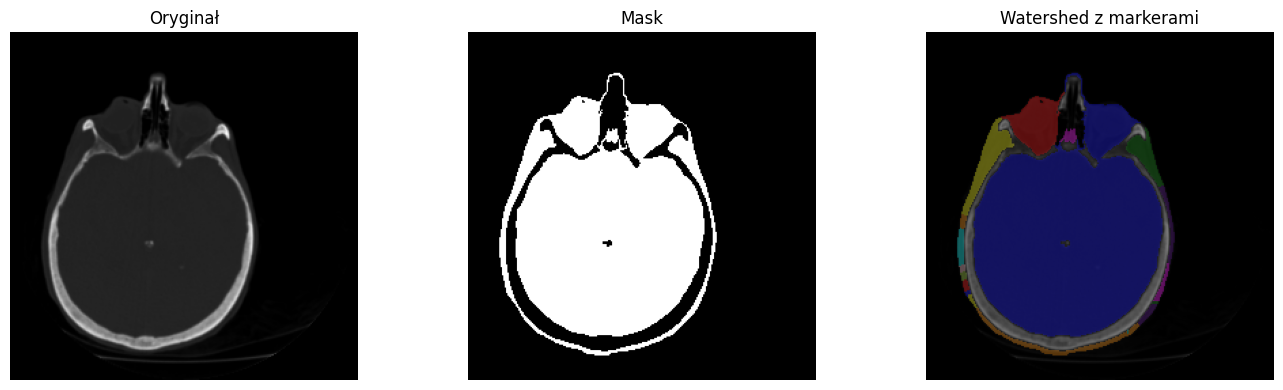

In [ ]:
img = data.brain()
img_f = img_as_float(img)

layer = 6

# sobel
grad = sobel(img_f[layer])

# watershed no markers
labels_plain = watershed(grad)
overlay = color.label2rgb(labels_plain, image=img[layer], bg_label=0)

show(
    [img_f[layer], grad, overlay],
    ["Oryginał", "Sobel","Watershed bez markerów"]
)

# watershed with markers
seed = (128, 128)
T = 0.05
mask_rg = region_growing(img[layer], seed, T)

markers = measure.label(morphology.erosion(mask_rg, morphology.disk(2)))

grad = sobel(gaussian(img_f[layer], sigma=1.0))

labels_mark = watershed(grad, markers=markers, mask=mask_rg)
overlay = color.label2rgb(labels_mark, image=img[layer], bg_label=0)

show(
    [img_f[layer], mask_rg, overlay],
    ["Oryginał", "Mask","Watershed z markerami"]
)

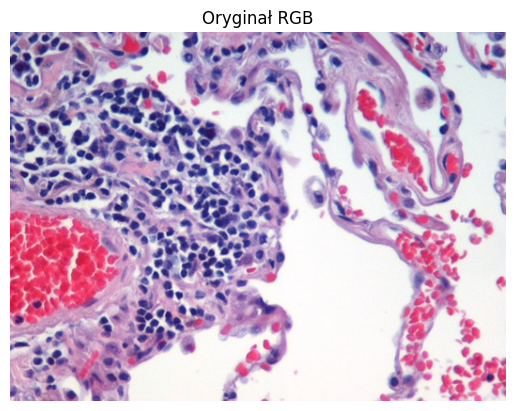

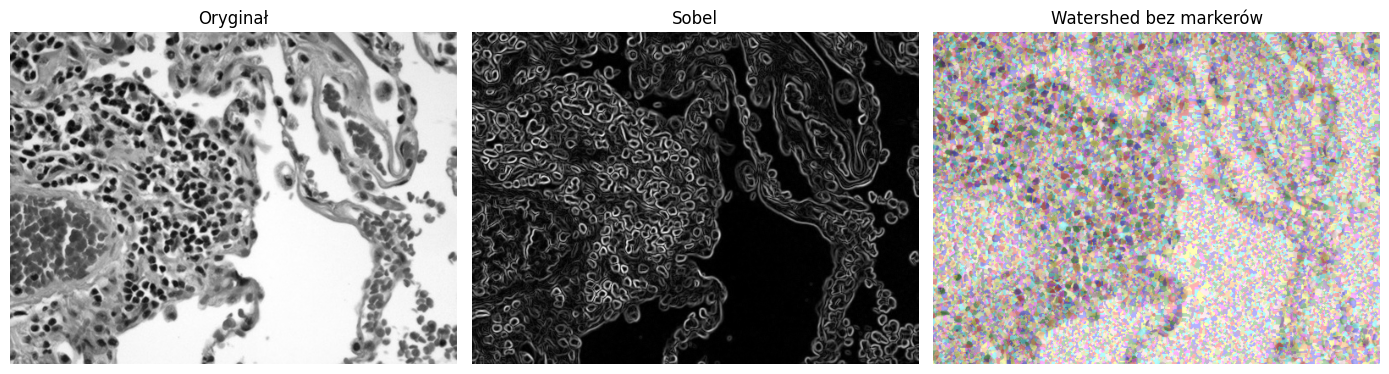

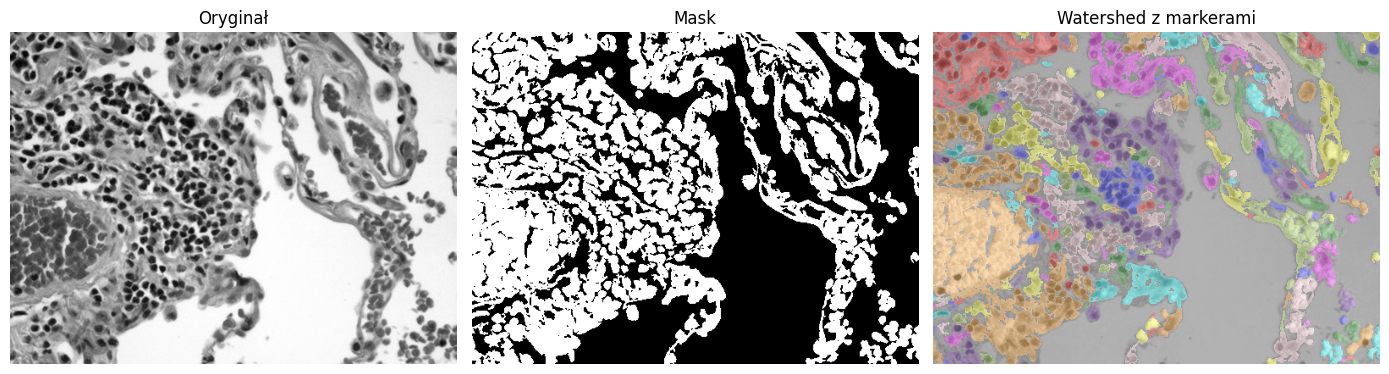

In [91]:
from skimage.color import rgb2gray

path = 'data/zadanie 2/Emphysema_H_and_E.jpg'

img = plt.imread(path, format='rgb')
img_f = img_as_float(rgb2gray(img))

plt.imshow(img_as_float(img))
plt.title("Oryginał RGB")
plt.axis('off')
plt.show()

# sobel
grad = sobel(img_f)

# watershed no markers
labels_plain = watershed(grad)
overlay = color.label2rgb(labels_plain, image=img, bg_label=0)

show(
    [img_f, grad, overlay],
    ["Oryginał", "Sobel","Watershed bez markerów"]
)

# watershed with markers
T = threshold_otsu(img_f)
bw = img_f < T
bw = morphology.remove_small_objects(bw, 50)

markers = measure.label(morphology.erosion(bw, morphology.disk(2)))

grad = sobel(gaussian(img_f, sigma=1.0))

labels_mark = watershed(grad, markers=markers, mask=bw)
overlay = color.label2rgb(labels_mark, image=img, bg_label=0)

show(
    [img_f, bw, overlay],
    ["Oryginał", "Mask","Watershed z markerami"]
)